In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import glob
import os

In [3]:
files = {
    "AlphaFold2": "./merged_with_class/merged_af2.csv",
    "Boltz-2": "./merged_with_class/merged_boltz.csv",
    "Chai-1": "./merged_with_class/merged_chai1.csv",
    "HelixFold3": "./merged_with_class/merged_helixfold3.csv",
    "OpenFold3": "./merged_with_class/merged_of3.csv",
    "Protenix": "./merged_with_class/merged_protenix.csv"
}

dfs = []

for model, filename in files.items():
    df = pd.read_csv(filename)
    df["model"] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

<function matplotlib.pyplot.show(close=None, block=None)>

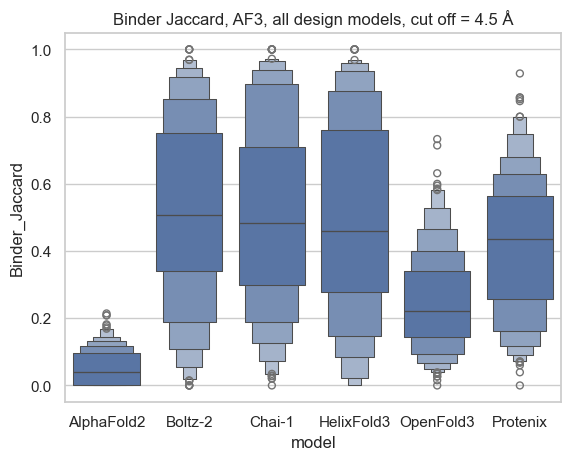

In [15]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_all,
    x="model",
    y="Binder_Jaccard",
    width_method="linear",
)
plt.title("Binder Jaccard, AF3, all design models, cut off = 4.5 Å")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

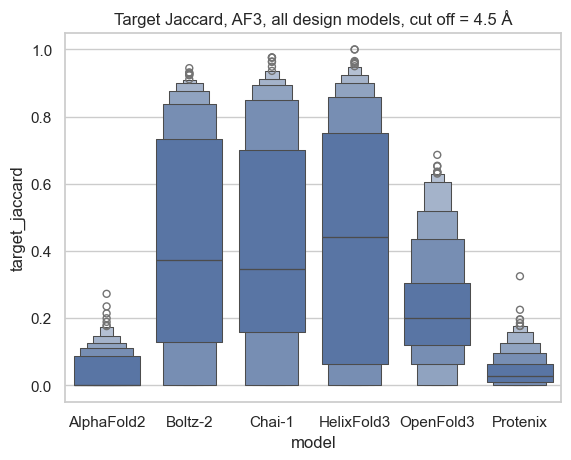

In [16]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_all,
    x="model",
    y="target_jaccard",
    width_method="linear",
)
plt.title("Target Jaccard, AF3, all design models, cut off = 4.5 Å")
plt.show

In [7]:
def load_selected_design_classes(files):
    """Load CSVs and keep only rows where design_class is Peptide or Miniprotein."""

    dfs = []
    desired = {"Peptide", "Miniprotein"}

    for model, filename in files.items():
        df = pd.read_csv(filename)

        # filter here
        df = df[df["design_class"].isin(desired)]

        df["model"] = model
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df_filtered = load_selected_design_classes(files)

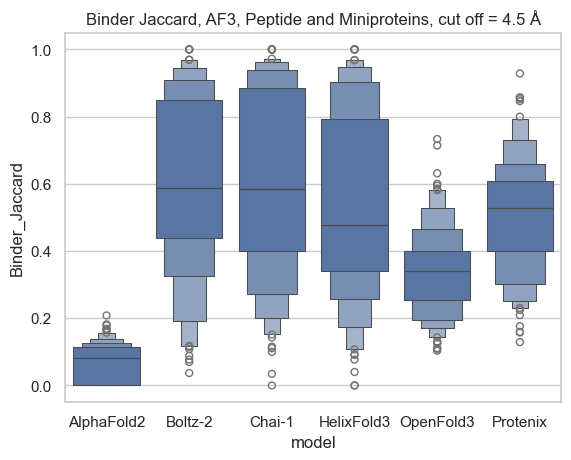

In [12]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_filtered,
    x="model",
    y="Binder_Jaccard",
    width_method="linear"
)
plt.title("Binder Jaccard, AF3, Peptide and Miniproteins, cut off = 4.5 Å")
plt.show()


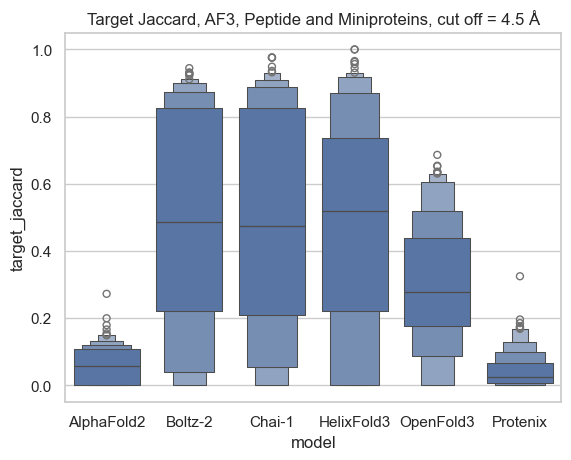

In [13]:
sns.set_theme(style="whitegrid")
sns.boxenplot(
    data=df_filtered,
    x="model",
    y="target_jaccard",
    width_method="linear"
)
plt.title("Target Jaccard, AF3, Peptide and Miniproteins, cut off = 4.5 Å")
plt.show()

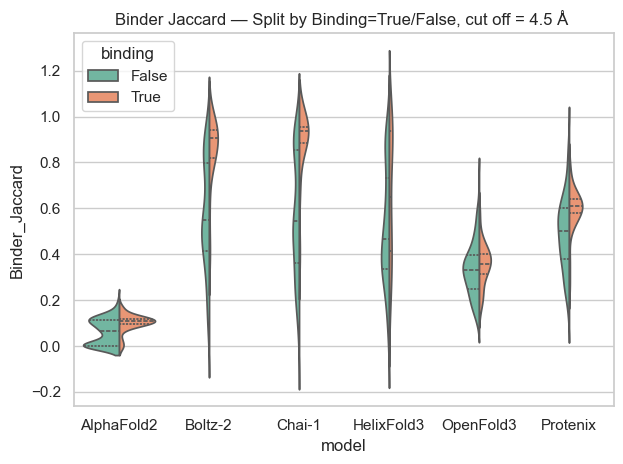

In [17]:

sns.violinplot(
    data=df_filtered,          # your filtered DF (Peptide + Miniprotein)
    x="model",
    y="Binder_Jaccard",
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Binder Jaccard — Split by Binding=True/False, cut off = 4.5 Å ")
plt.tight_layout()
plt.show()


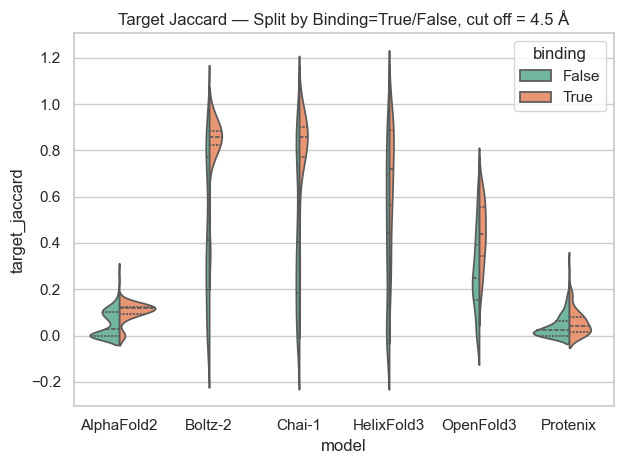

In [18]:

sns.violinplot(
    data=df_filtered,          # your filtered DF (Peptide + Miniprotein)
    x="model",
    y="target_jaccard",
    hue="binding",             # split by True/False
    split=True,                # the magic option
    inner="quartile",          # shows quartile lines
    palette="Set2"
)

plt.title("Target Jaccard — Split by Binding=True/False, cut off = 4.5 Å")
plt.tight_layout()
plt.show()
